# Tracking AI Trends Through NLP-Powered Text Mining and Knowledge Extraction

## Stage 3: Implementing a RAG System for Question Answering

### AI Media Dataset

This notebook covers:
1. Q&A Dataset Construction
2. Knowledge Graph Integration
3. RAG Implementation
4. System Evaluation
5. Enhancement Proposal
6. AI Disclaimer
7. Contributions

By: Samuel Amuzu, Nick Schaufelberger, Julian Purtschert

Folder with all the files to run the notebook: https://drive.google.com/drive/folders/1qowf_4CXY2jG3vblTDrM9KromGpM7VEa?usp=sharing

## Libraries

In [ ]:
# Load libraries
import pandas as pd
import os
import re
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random
from collections import Counter, defaultdict
import google.generativeai as genai
from google.colab import userdata
import json
import time
import requests
import networkx as nx
import seaborn as sns

## 1. Data Collection

Since we had already processed the data in Stages 1 and 2, we exported the preprocessed data as a CSV file and loaded it to continue our analysis and implementation of the RAG system in Stage 3.

### 1.1 Data Loading

In [ ]:
# Mount Google Drive to access project files stored in the cloud
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


For Stage 3, we load both the raw and cleaned datasets to ensure flexibility in our next steps.

In [ ]:
# Load data and Explore the data
df_raw = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_media_dataset_20250911.csv")
df_cleaned = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/ai_media_stage1_output.csv")
df_cleaned.head()

,title,date,content,domain,url,tags,content_clean,content_processed
0,Ricoh to provide customer support for Agility ...,2024-09-11,['The Digit humanoid could work in distributio...,therobotreport,https://www.therobotreport.com/ricoh-provides-...,"['Robotics', 'Video', 'BostonDynamics']",the digit humanoid could work in distribution ...,digit humanoid work distribution retail commer...
1,MTV VMAs 2024: Live shopping is coming to the ...,2024-09-11,"['In this article', ""When viewers tune in to t...",cnbc,https://www.cnbc.com/2024/09/11/mtv-vmas-2024-...,['GenerativeAI'],in this article when viewers tune in to the 20...,article viewer tune mtv vmas wednesday night a...
2,Open-source imagery is transforming investigat...,2024-09-11,['Open-source online imagery can play a vital ...,theconversation,https://www.theconversation.com/open-source-im...,"['Disinformation', 'Video', 'Deepfake', 'Infor...",open source online imagery can play a vital ro...,open source online imagery play vital role inv...
3,"With China seeking AI dominance, Taiwan’ s eff...",2024-09-11,"['Tensions between China, Taiwan and the U.S. ...",theconversation,https://www.theconversation.com/with-china-see...,"['MilitaryAndDefense', 'Missiles', 'HighPerfor...",tensions between china taiwan and the you s ar...,tension china taiwan limited aerial military m...
4,Study links EV charging stations to increased ...,2024-09-11,['Countries globally are rapidly transitioning...,phys,https://phys.org/news/2024-09-links-ev-station...,"['Causality', 'Planning']",countries globally are rapidly transitioning t...,country globally rapidly transitioning cleaner...


We inspect the shape, column names, and missing value counts of the cleaned dataset to confirm it is ready for further processing.

In [ ]:
print("Dataset Shape:", df_cleaned.shape)
print("\nColumn Names:", df_cleaned.columns.tolist())
print("\nMissing Values:")
print(df_cleaned.isnull().sum())

Dataset Shape: (16527, 8)

Column Names: ['title', 'date', 'content', 'domain', 'url', 'tags', 'content_clean', 'content_processed']

Missing Values:
title                0
date                 0
content              0
domain               0
url                  0
tags                 0
content_clean        0
content_processed    0
dtype: int64


## 1.3 Sampling representative passages (topic-stratified)

We began by initializing the OpenAI client using our API key, which we retrieved securely from the environment. We then defined our key configuration parameters: we chose GPT-3.5-turbo as our model, set the number of passages to 75, and decided to generate 3 question-answer pairs per passage. To ensure reproducibility, we fixed the random seed to 42 and added a short wait of 0.5 seconds between API calls to avoid rate limiting issues.

In [ ]:
from openai import OpenAI
client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

# Set configuration
MODEL              = "gpt-3.5-turbo"
N_PASSAGES         = 75
N_QA_PER_PASSAGE   = 3
SEED               = 42
WAIT_BETWEEN_CALLS = 0.5

print(f"OpenAI client ready  ({MODEL}).")

OpenAI client ready  (gpt-3.5-turbo).


## 1.4 Topic Stratification & Passage Sampling

We defined a helper function to parse the tags column, which was stored as a stringified list rather than an actual Python list. Since some entries could be missing, we first handled NaN values by returning an empty list. We then used a regular expression to extract individual tag strings, accounting for both single and double-quoted formats as well as unquoted alphanumeric tags. Finally, we applied this function to the entire cleaned dataframe, storing the resulting lists in a new column called tags_list.

In [ ]:
# Parse tags column (stored as a stringified list)
def parse_tags(tag_str):
    """Return a list of tag strings from the raw tags field."""
    if pd.isna(tag_str):
        return []
    tags = re.findall(r"'([^']+)'|\"([^\"]+)\"|([A-Za-z][A-Za-z0-9]+)", str(tag_str))
    return [next(t for t in group if t) for group in tags]

df_cleaned["tags_list"] = df_cleaned["tags"].apply(parse_tags)

We set the random seed to 42 to ensure reproducibility and then manually defined ten topic groups, each containing a set of relevant tags that we associated with a broader AI-related theme. To assign each article to a group, we wrote a function that iterates through the topic groups in order and returns the first matching group based on the article's tags, falling back to "Other" if no match was found. We applied this function to the tags_list column and stored the results in a new column called topic_group. Finally, we printed the value counts to get an overview of how many articles fell into each category.

In [ ]:
# For reproducibility
random.seed(42)

# Assigning tags to topic_groups
topic_groups = {
    "GenerativeAI":          ['GenerativeAI', 'DALLE', 'StableDiffusion', 'ImageGeneration', 'Text2Image'],
    "LLMs":                  ['LargeLanguageModel', 'GPT4', 'Llama', 'Claude', 'Gemini', 'DeepSeek', 'ChatGPT'],
    "Robotics":              ['Robotics', 'BostonDynamics', 'RoboticArm', 'AutonomousDriving', 'Drone'],
    "Ethics":                ['EthicalAI', 'Fairness', 'AlgorithmicBias', 'ResponsibleAI', 'Disinformation'],
    "Regulation":            ['AIAct', 'AIPolicy', 'AISafety', 'Accountability'],
    "NLP":                   ['NaturalLanguageProcessing', 'SentimentAnalysis', 'NamedEntityRecognition', 'TextSummarization'],
    "ComputerVision":        ['ComputerVision', 'FaceRecognition', 'ImageClassification', 'ObjectRecognition'],
    "HealthcareAI":          ['DrugDiscovery', 'MedicalImaging', 'BioBERT'],
    "MilitarySecurity":      ['MilitaryAndDefense', 'Surveillance', 'Deepfake', 'Biometrics'],
    "ReinforcementLearning": ['ReinforcementLearning', 'DeepReinforcementLearning', 'QLearning'],
}

# Label each row with its topic group
def assign_group(tags):
    for group_name, group_tags in topic_groups.items():
        if any(tag in group_tags for tag in tags):
            return group_name
    # Articles that do not match any group
    return "Other"

# Assign function to the tags column
df_cleaned['topic_group'] = df_cleaned['tags_list'].apply(assign_group)

# See how many articles fall into each topic_group
print(df_cleaned['topic_group'].value_counts())

topic_group
GenerativeAI             4372
Other                    3925
LLMs                     2786
Robotics                 2056
MilitarySecurity          824
Regulation                736
Ethics                    631
HealthcareAI              444
NLP                       379
ComputerVision            331
ReinforcementLearning      43
Name: count, dtype: int64


 ## 1.5 Filter and sample passages

Before sampling, we remove articles whose content_clean field is missing or contains fewer than 100 words. Very short texts carry insufficient context for meaningful question generation and would produce low-quality Q&A pairs. In the print out its clear there are no articles with less than 100 words.

In [ ]:
# Filter
df_filtered = df_cleaned.dropna(subset=["content_clean"]).copy()
df_filtered["word_count"] = df_filtered["content_clean"].str.split().str.len()
df_filtered = df_filtered[df_filtered["word_count"] >= 100].reset_index(drop=True)
print(f"Articles after filtering (≥100 words): {len(df_filtered):,}")

Articles after filtering (≥100 words): 16,527


We aimed to sample exactly 75 passages from our filtered dataset in a way that reflects the proportional distribution of topic groups. To avoid the "Other" category from dominating the sample, we capped it at a maximum of 4 passages and redistributed the remaining proportionally across all other topics, ensuring each received at least 3 passages.

In [ ]:
np.random.seed(SEED)

topic_sizes = df_filtered["topic_group"].value_counts()
proportions = (topic_sizes / topic_sizes.sum() * N_PASSAGES).round().astype(int)

# Cap "Other" first
if "Other" in proportions:
    proportions["Other"] = min(proportions["Other"], 4)

# Re-normalize remaining budget across non-Other topics
remaining_budget = N_PASSAGES - proportions["Other"]
non_other        = proportions[proportions.index != "Other"]
non_other        = (non_other / non_other.sum() * remaining_budget).round().astype(int)
non_other        = non_other.clip(lower=3)
proportions      = pd.concat([non_other, proportions[["Other"]]])

# Trim to N_PASSAGES
while proportions.sum() > N_PASSAGES:
    proportions[proportions.idxmax()] -= 1

sampled_parts = []
for topic, n in proportions.items():
    pool = df_filtered[df_filtered["topic_group"] == topic]
    n    = min(n, len(pool))
    sampled_parts.append(pool.sample(n, random_state=SEED))

df_passages = pd.concat(sampled_parts).reset_index(drop=True)
print(f"\nSampled {len(df_passages)} passages:")
print(df_passages["topic_group"].value_counts().to_string())
df_passages[["title", "topic_group", "domain", "word_count"]].head(10)


Sampled 75 passages:
topic_group
GenerativeAI             19
LLMs                     16
Robotics                 11
MilitarySecurity          5
Regulation                4
Ethics                    4
Other                     4
HealthcareAI              3
NLP                       3
ComputerVision            3
ReinforcementLearning     3


,title,topic_group,domain,word_count
0,Vincent Hunt - The Bureau of Creative Intellig...,GenerativeAI,thedigitalspeaker,3016
1,Advancing AI across insurance,GenerativeAI,kpmg,1305
2,PNC’ s Responsible Approach to AI Innovation,GenerativeAI,builtin,794
3,Lenovo Showcases New AI-Powered Solutions with...,GenerativeAI,hpcwire,1678
4,"European Robot Makers Adopt NVIDIA Isaac, Omni...",GenerativeAI,blogs.nvidia,976
5,Qualcomm unveils Snapdragon 8 Elite as world’ ...,GenerativeAI,venturebeat,1149
6,Anders Jensen Discusses EuroHPC Ahead of SC24,GenerativeAI,hpcwire,3526
7,Personalization: AI for Retail Marketing Magic,GenerativeAI,bain,1875
8,NVIDIA Showcases Real-Time AI and Intelligent ...,GenerativeAI,blogs.nvidia,1033
9,Financial Services Firms Will Bank On Homegrow...,GenerativeAI,nextplatform,2991


## 1.6 Generating Q&A pairs with an LLM (OpenAI - ChatGPT)

### 1.6.1 Prompt builder

We define a structured system prompt that instructs the LLM to produce exactly three Q&A pairs per passage. One factual, one analytical, and one comparative. All answers must be grounded solely in the supplied passage text. The model is asked to return its output as a JSON array, which we then parse and validate.

In [ ]:
QA_SYSTEM_PROMPT = """You are an expert annotator building a high-quality evaluation
dataset for a Retrieval-Augmented Generation (RAG) system focused on AI media news.

Given a news passage, generate exactly 3 question-answer pairs that cover DIFFERENT
question types:
  • factual     — asks for a specific fact, entity, date, or number stated in the passage
  • analytical  — asks for an explanation, cause, implication, or mechanism described
  • comparative — asks to compare, contrast, or relate two things mentioned in the passage

Rules:
1. Every answer must be fully grounded in the passage; do not add external knowledge.
2. Questions must be self-contained (a reader without the passage should understand them).
3. Answers should be 1–3 sentences, concise and precise.
4. If no clear comparison exists in the passage, make the comparative question relate
   the topic to a broader AI concept mentioned in the passage.
5. Return ONLY valid JSON — no markdown fences, no preamble, no trailing text.

Output format (strict):
[
  {"question": "...", "answer": "...", "type": "factual",     "passage_id": "<id>"},
  {"question": "...", "answer": "...", "type": "analytical",  "passage_id": "<id>"},
  {"question": "...", "answer": "...", "type": "comparative", "passage_id": "<id>"}
]"""

def build_user_prompt(passage_id: str, title: str, topic: str, text: str) -> str:
    words = text.split()
    truncated = " ".join(words[:800])
    return (
        f"Passage ID: {passage_id}\n"
        f"Topic: {topic}\n"
        f"Title: {title}\n\n"
        f"Passage:\n{truncated}\n\n"
        "Generate 3 Q&A pairs as specified."
    )

The function takes a single passage and sends it to the OpenAI API to generate question-answer pairs. For each passage, we first built a structured user prompt using the passage's metadata and content, then sent it to the model along with a system prompt at a low temperature of 0.3 to keep the outputs focused and consistent. Since the API occasionally returns JSON wrapped in markdown code fences, we stripped those before parsing the response.

In [ ]:
def generate_qa_for_passage(row: pd.Series, max_retries: int = 3) -> list[dict]:
    passage_id  = str(row.name)
    user_prompt = build_user_prompt(
        passage_id = passage_id,
        title      = str(row.get("title", "")),
        topic      = str(row.get("topic", "")),
        text       = str(row.get("content_clean", ""))
    )

    for attempt in range(1, max_retries + 1):
        try:
            response = client.chat.completions.create(
                model    = MODEL,
                messages = [
                    {"role": "system", "content": QA_SYSTEM_PROMPT},
                    {"role": "user",   "content": user_prompt}
                ],
                temperature = 0.3,
                max_tokens  = 1024,
            )
            raw = response.choices[0].message.content.strip()
            raw = re.sub(r"^```(?:json)?", "", raw).strip()
            raw = re.sub(r"```$",          "", raw).strip()

            parsed = json.loads(raw)
            pairs  = parsed if isinstance(parsed, list) else next(
                (v for v in parsed.values() if isinstance(v, list)), []
            )

            valid = []
            for p in pairs:
                if all(k in p for k in ("question", "answer", "type")):
                    p["passage_id"] = passage_id
                    p["title"]      = str(row.get("title", ""))
                    p["topic"]      = str(row.get("topic", ""))
                    p["domain"]     = str(row.get("domain", ""))
                    p["url"]        = str(row.get("url", ""))
                    valid.append(p)
            return valid

        except json.JSONDecodeError as e:
            print(f"  [passage {passage_id}] JSON error attempt {attempt}: {e}")
            time.sleep(2)
        except Exception as e:
            err = str(e)
            if "429" in err or "rate" in err.lower():
                wait = 30 * attempt
                print(f"  [passage {passage_id}] Rate limited — waiting {wait}s")
                time.sleep(wait)
            else:
                print(f"  [passage {passage_id}] Error attempt {attempt}: {e}")
                time.sleep(5 * attempt)

    return []

print("Function loaded. Client type:", type(client).__name__)

Function loaded. Client type: OpenAI


All 75 sampled passages are called our generation function on each one, collecting the resulting question-answer pairs into a single list while keeping track of any passages that failed to produce valid output. After each API call we paused briefly to respect the rate limit, and we printed a running total to monitor progress throughout the loop. Once all passages were processed, we printed a summary showing how many succeeded and how many failed.

In [ ]:
all_qa_pairs = []
failed_ids   = []

for i, (idx, row) in enumerate(df_passages.iterrows()):
    print(f"[{i+1}/{len(df_passages)}] {row['title'][:70]}...")
    pairs = generate_qa_for_passage(row)
    if pairs:
        all_qa_pairs.extend(pairs)
        print(f"  → {len(pairs)} pairs  (running total: {len(all_qa_pairs)})")
    else:
        failed_ids.append(idx)
        print(f"  → FAILED")
    time.sleep(WAIT_BETWEEN_CALLS)

print(f"\n{'='*60}")
print(f"Passages processed : {len(df_passages)}")
print(f"Passages failed    : {len(failed_ids)}  {failed_ids if failed_ids else ''}")
print(f"Total Q&A pairs    : {len(all_qa_pairs)}")

# Retry failed passages
if failed_ids:
    print("\nRetrying failed passages...")
    for idx in failed_ids:
        row = df_passages.loc[idx]
        pairs = generate_qa_for_passage(row, max_retries=5)
        if pairs:
            all_qa_pairs.extend(pairs)
            print(f"  → passage {idx} recovered: {len(pairs)} pairs")

# Convert to dataframe
df_qa = pd.DataFrame(all_qa_pairs)
print(df_qa["type"].value_counts())
print(df_qa["topic_group"].value_counts())
df_qa.head()

[1/75] Vincent Hunt - The Bureau of Creative Intelligence...
  → 3 pairs  (running total: 3)
[2/75] Advancing AI across insurance...


KeyboardInterrupt: 

The collected question-answer pairs were converted into a dataframe and the type column was cleaned by lowercasing and stripping whitespace, followed by replacing inconsistent variants such as "fact" or "analytic" with their standardized forms. A unique identifier column called qa_id was then inserted as the first column, assigning each row a zero-padded ID in the format QA_0001. Finally, the total number of rows and the distribution of question types were printed to confirm the normalization worked as expected.

In [ ]:
df_qa = pd.DataFrame(all_qa_pairs)

# Normalise type column
df_qa["type"] = (
    df_qa["type"]
    .str.lower()
    .str.strip()
    .replace({
        "fact":     "factual",
        "facts":    "factual",
        "analytic": "analytical",
        "compare":  "comparative",
    })
)

df_qa.insert(0, "qa_id", [f"QA_{i:04d}" for i in range(len(df_qa))])

print(f"Rebuilt df_qa: {len(df_qa)} rows")
print(df_qa["type"].value_counts().to_string())

Rebuilt df_qa: 3 rows
type
factual        1
analytical     1
comparative    1


A quick sanity check was performed by inspecting the sixth question-answer pair in the dataset. The corresponding passage was retrieved from df_passages using the passage_id stored in the row, and its first 200 words were printed alongside the qa_id, question type, topic and source title. This allowed us to visually verify that the generated question and answer were coherent and grounded in the actual passage content.

In [ ]:
# Quick look at Q&A pair #5
row     = df_qa.iloc[5]
passage = df_passages.loc[int(row["passage_id"])]

print(f"qa_id   : {row['qa_id']}")
print(f"type    : {row['type']}")
print(f"topic   : {row['topic']}")
print(f"source  : {row['title']}")

words = str(passage["content_clean"]).split()
print(f"\nPassage (first 200 words):\n{' '.join(words[:200])}")

print(f"\nQ: {row['question']}")
print(f"A: {row['answer']}")

qa_id   : QA_0005
type    : comparative
topic   : GenerativeAI
source  : Advancing AI across insurance

Passage (first 200 words):
artificial intelligence is becoming a key priority as insurance organisations navigate complexity in a fast paced world the evolution of artificial intelligence ai including the new wave of generative ai gen ai is transforming numerous industries whether it x80 x99s automated claims assessing risk personalisation of products and services or fighting cyber crime insurance organisations are increasingly looking towards ai to help tackle complex and time intensive tasks and to streamline processes there is an urgent need to pick up the pace in adoption of artificial intelligence despite the use of ai in a handful of areas and pilots taking place elsewhere insurance companies are not gaining an advantage on competitors by using this technology more widely doing so could enable businesses to work faster more flexibly and develop more sophisticated models in resp

Since generating all 225 Q&A pairs takes a while and costs API calls, we exported the finished dataset to a CSV straight away. This way if the Colab session crashes or needs to be restarted, we don't have to re-run the whole generation loop. We can just reload the CSV and pick up from where I left off.

In [ ]:
#from google.colab import files
#df_qa[["qa_id", "type", "topic", "domain", "title", "url", "passage_id", "question", "answer"]].to_csv("qa_dataset.csv", index=False)
#files.download("qa_dataset.csv")

### 1.6.2 Manually review and refine Q&A pairs for correctness and coverage

To ensure quality and correctness, we manually reviewed a sample of the generated Q&A pairs, spot-checking answers against their source passages. A few factual questions were slightly rephrased for clarity, and one or two comparative pairs that felt too vague were tightened up. Overall the LLM did a solid job staying grounded in the passages, with only minor refinements needed across the dataset.

**Example 1:** Question: How does the use of generative AI in insurance relate to the concerns around data quality, bias, and regulatory compliance?


**Before:** "Generative AI is seen as a double-edged sword in the insurance industry, as it can aid in detecting cyber attacks but also provide new attack strategies for adversaries."


**After:** "Generative AI creates real tension in insurance, it helps automate risk assessment and personalise products, but introduces new concerns around data quality, model bias, and whether decisions can be explained to regulators.

We felt the original answer completely missed the three concepts the question actually asked about (data quality, bias, compliance) and replaced them with cybersecurity points from a different passage.

In [ ]:
df_qa = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/qa_dataset.csv")
print(f"Loaded {len(df_qa)} Q&A pairs")
print(df_qa["type"].value_counts())
df_qa.head(6)

Loaded 225 Q&A pairs
type
factual        75
analytical     75
comparative    75
Name: count, dtype: int64


,qa_id,type,topic,domain,title,url,passage_id,question,answer
0,QA_0000,factual,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,What is the purpose of GenerativeAI according ...,"GenerativeAI is focused on capturing intent, w..."
1,QA_0001,analytical,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,How does Vincent Hunt demonstrate innovation a...,Vincent innovates by finding new and different...
2,QA_0002,comparative,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,How does the concept of generative design rela...,Generative design and associated AI algorithms...
3,QA_0003,factual,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,What are some areas in the insurance industry ...,"AI is being used for automated claims, assessi..."
4,QA_0004,analytical,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,How does the slow pace of AI implementation in...,Insurance companies are ahead of the global av...
5,QA_0005,comparative,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,How does the use of generative AI in insurance...,Generative AI is seen as a double-edged sword ...


In [ ]:
df_qa.head(7)

,qa_id,type,topic,domain,title,url,passage_id,question,answer
0,QA_0000,factual,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,What is the purpose of GenerativeAI according ...,"GenerativeAI is focused on capturing intent, w..."
1,QA_0001,analytical,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,How does Vincent Hunt demonstrate innovation a...,Vincent innovates by finding new and different...
2,QA_0002,comparative,GenerativeAI,thedigitalspeaker,Vincent Hunt - The Bureau of Creative Intellig...,https://www.linkedin.com/in/vincenthunt,0,How does the concept of generative design rela...,Generative design and associated AI algorithms...
3,QA_0003,factual,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,What are some areas in the insurance industry ...,"AI is being used for automated claims, assessi..."
4,QA_0004,analytical,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,How does the slow pace of AI implementation in...,Insurance companies are ahead of the global av...
5,QA_0005,comparative,GenerativeAI,kpmg,Advancing AI across insurance,https://www.kpmg.com/au/en/home/insights/2024/...,1,How does the use of generative AI in insurance...,Generative AI is seen as a double-edged sword ...
6,QA_0006,factual,GenerativeAI,builtin,PNC’ s Responsible Approach to AI Innovation,https://builtin.com/articles/pncs-responsible-...,2,What approach does PNC Bank take towards imple...,PNC Bank balances innovation and responsibilit...


## 2. Knowledge Graph Integration

We fetch the baseline KG from the provided Graph API and use it to enrich
RAG context. For each user question we:
1. Retrieve top-k passages via vector similarity (standard RAG)
2. Extract key entities from the question and look them up in the KG
3. Fuse text context + graph context into a single augmented prompt
4. Compare answers: RAG-only vs RAG+KG

The baseline knowledge graph is fetched from the course API as a JSON object containing two lists: nodes representing named AI entities, and connections representing directed relationships between them. Both are loaded into DataFrames to allow fast lookup and filtering during retrieval. Each node carries metadata including its type, popularity score, and trend value, while each edge records the strength of the relationship between its source and target.

In [ ]:
# Inspect structure
KG_URL = "http://85.214.245.200:7004/graph"

response = requests.get(KG_URL, timeout=30)
kg_data  = response.json()

nodes       = kg_data["nodes"]
connections = kg_data["connections"]

df_nodes = pd.DataFrame(nodes)
df_edges = pd.DataFrame(connections)

In [ ]:
print(df_nodes.head())
print(df_nodes.columns.tolist())
print(df_edges.head())
print(df_edges.columns.tolist())

                name                                nodeId  popularity  \
0    Graph Analytics  81664403-5fad-4825-9727-178632614d60       100.0   
1   Algorithmic Bias  f0b44bcb-0abc-42e2-84cf-fc041deaa38d       100.0   
2  Data Exploitation  96fdcab5-d94b-4559-a663-a52c19db064a       100.0   
3             MLFlow  9dd8b2ff-347f-4e48-8bc3-1c1b6dea031e       100.0   
4        Llama Index  deb310a7-4008-4557-88aa-47691008e964       100.0   

                                   short_description      trend           type  
0  Analyze graph-structured data to uncover patte...     rising           Task  
1  Unfair, discriminatory AI outcomes from biased...  declining    RiskConcept  
2  Risk of misuse or unauthorized exploitation of...     rising    RiskConcept  
3  Open-source ML lifecycle management platform f...     rising  ToolFramework  
4  Framework for integrating data with LLMs for R...     rising  ToolFramework  
['name', 'nodeId', 'popularity', 'short_description', 'trend', 'type'

## 2.1 KG from Stage 1

Alongside the baseline graph, we reload the knowledge graph we constructed in Stage 1 from its exported pickle file. This graph was built by extracting named entities and co-occurrence relationships directly from the raw article corpus, so it reflects the actual language and topics of the dataset rather than a pre-curated ontology.

In [ ]:
import pickle
with open("/content/drive/MyDrive/Colab Notebooks/knowledge_graph.pkl", "rb") as f:
    G = pickle.load(f)

print(type(G))
print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

<class 'networkx.classes.graph.Graph'>
Nodes: 40493
Edges: 31931


In [ ]:
# Inspect a few nodes
print("Sample nodes:")
for node, data in list(G.nodes(data=True))[:5]:
    print(f"  {node}: {data}")

# Inspect a few edges
print("\nSample edges:")
for u, v, data in list(G.edges(data=True))[:5]:
    print(f"  {u} -> {v}: {data}")

Sample nodes:
  Ricoh USA Inc: {'frequency': 1}
  Agility: {'frequency': 3}
  Ricoh: {'frequency': 2}
  Agility Robotics Inc: {'frequency': 1}
  Digit: {'frequency': 4}

Sample edges:
  Digit -> Agility Robotics: {'weight': 3}
  North America -> Europe: {'weight': 15}
  North America -> ASIC: {'weight': 3}
  North America -> Hut 8 Corp: {'weight': 9}
  North America -> Nasdaq: {'weight': 9}


After loading the Stage 1 knowledge graph from the exported pickle file, we did a quick inspection to understand its structure. The graph contains 40'493 nodes and 31'931 edges, where each node represents a named entity extracted from the dataset and carries a frequency attribute indicating how often it appeared across articles.

To measure each node's relative importance within the baseline graph, we compute a connection count by tallying how often each node appears as either the source or target of an edge. This gives a simple but effective centrality proxy: nodes with high connection counts are entities that frequently relate to others in the graph, making them more likely to provide useful context when surfacing graph facts during retrieval.

In [ ]:
# Count connections per node from the edges list for the Baseline KG
conn_counts = {}
for e in connections:
    conn_counts[e["sourceNodeId"]] = conn_counts.get(e["sourceNodeId"], 0) + 1
    conn_counts[e["targetNodeId"]] = conn_counts.get(e["targetNodeId"], 0) + 1
df_nodes["connection_count"] = df_nodes["nodeId"].map(conn_counts).fillna(0).astype(int)

print(f"Nodes      : {len(df_nodes)}")
print(f"Connections: {len(df_edges)}")
print(f"\nNode types:\n{df_nodes['type'].value_counts().to_string()}")
print(f"\nTrend values:\n{df_nodes['trend'].value_counts().to_string()}")
print(f"\nTop 10 nodes by connection count:")
print(df_nodes.nlargest(10, 'connection_count')[
    ['name', 'type', 'connection_count', 'popularity', 'trend']
].to_string())

Nodes      : 1947
Connections: 2560

Node types:
type
Company              1339
use_case              219
ModelFamily            91
Task                   73
ToolFramework          42
EngineeringMethod      38
ModelArchitecture      37
Dataset                37
Algorithm              27
LearningParadigm       20
Infrastructure         14
RiskConcept             9
InterfacePattern        1

Trend values:
trend
0.5          1339
unknown       390
declining     114
rising        104

Top 10 nodes by connection count:
                        name               type  connection_count  popularity      trend
256     Large Language Model        ModelFamily                91      100.00  declining
6              Deep Learning   LearningParadigm                86      100.00  declining
449        Generative Design           use_case                48        1.00    unknown
524  Digital Twin Simulation           use_case                48        0.94    unknown
436          Code Generation       

In [ ]:
# Summarise the Stage 1 graph
node_degrees = dict(G.degree())
edge_weights = [d["weight"] for _, _, d in G.edges(data=True)]

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

print(f"\nTop 10 nodes by degree:")
top_nodes = sorted(node_degrees.items(), key=lambda x: x[1], reverse=True)[:10]
for node, degree in top_nodes:
    freq = G.nodes[node].get("frequency", 0)
    print(f"  {node:<40} degree: {degree}  frequency: {freq}")

print(f"\nTop 10 edges by weight:")
top_edges = sorted(G.edges(data=True), key=lambda x: x[2]["weight"], reverse=True)[:10]
for u, v, d in top_edges:
    print(f"  {u:<30} -> {v:<30} weight: {d['weight']}")

Nodes: 40493
Edges: 31931

Top 10 nodes by degree:
  AI                                       degree: 3467  frequency: 5356
  AIAI                                     degree: 934  frequency: 1590
  Google                                   degree: 651  frequency: 886
  U. S.                                    degree: 625  frequency: 848
  OpenAI                                   degree: 562  frequency: 749
  Trump                                    degree: 499  frequency: 485
  China                                    degree: 440  frequency: 533
  United States                            degree: 407  frequency: 514
  US                                       degree: 403  frequency: 483
  Microsoft                                degree: 395  frequency: 478

Top 10 edges by weight:
  AI                             -> AIAI                           weight: 920
  AI                             -> OpenAI                         weight: 517
  LinkedIn                       -> TNS              

## 2.2 Comparison of the two Graphs

With both graphs loaded, we now compare them across three dimensions: size and density, entity overlap, and the identity of their most central nodes. This comparison helps us understand what each graph contributes and whether they are complementary or redundant.

In [ ]:
baseline_nodes = set(df_nodes["name"].str.lower())
stage1_nodes   = set(n.lower() for n in G.nodes())

overlap        = baseline_nodes & stage1_nodes
only_baseline  = baseline_nodes - stage1_nodes
only_stage1    = stage1_nodes   - baseline_nodes

print(f"Baseline nodes : {len(baseline_nodes)}")
print(f"Stage 1 nodes  : {len(stage1_nodes)}")
print(f"Overlap        : {len(overlap)}")
print(f"Only baseline  : {len(only_baseline)}")
print(f"Only Stage 1   : {len(only_stage1)}")

Baseline nodes : 1934
Stage 1 nodes  : 39828
Overlap        : 487
Only baseline  : 1447
Only Stage 1   : 39341


In [ ]:
#Size & Density
print("=" * 50)
print("SIZE & DENSITY")
print("=" * 50)

baseline_density = len(df_edges) / (len(df_nodes) * (len(df_nodes) - 1) / 2)
stage1_density   = nx.density(G)

baseline_avg_degree = df_nodes["connection_count"].mean()
stage1_avg_degree   = sum(dict(G.degree()).values()) / G.number_of_nodes()

print(f"{'':25} {'Baseline':>12} {'Stage 1':>12}")
print(f"{'Nodes':25} {len(df_nodes):>12,} {G.number_of_nodes():>12,}")
print(f"{'Edges':25} {len(df_edges):>12,} {G.number_of_edges():>12,}")
print(f"{'Density':25} {baseline_density:>12.6f} {stage1_density:>12.6f}")
print(f"{'Avg degree':25} {baseline_avg_degree:>12.2f} {stage1_avg_degree:>12.2f}")

SIZE & DENSITY
                              Baseline      Stage 1
Nodes                            1,947       40,493
Edges                            2,560       31,931
Density                       0.001351     0.000039
Avg degree                        2.63         1.58


In [ ]:
#Entity Overlap
print(f"\n{'=' * 50}")
print("ENTITY OVERLAP")
print("=" * 50)

baseline_nodes_set = set(df_nodes["name"].str.lower())
stage1_nodes_set   = set(n.lower() for n in G.nodes())

overlap        = baseline_nodes_set & stage1_nodes_set
only_baseline  = baseline_nodes_set - stage1_nodes_set
only_stage1    = stage1_nodes_set   - baseline_nodes_set

print(f"Overlap        : {len(overlap):,}")
print(f"Only baseline  : {len(only_baseline):,}")
print(f"Only Stage 1   : {len(only_stage1):,}")


ENTITY OVERLAP
Overlap        : 487
Only baseline  : 1,447
Only Stage 1   : 39,341


In [ ]:
#Top 10 nodes
print(f"\n{'=' * 50}")
print("TOP 10 NODES BY DEGREE")
print("=" * 50)

print(f"\nBaseline:")
print(df_nodes.nlargest(10, "connection_count")[["name", "type", "connection_count"]].to_string(index=False))

print(f"\nStage 1:")
top_stage1 = sorted(G.degree(), key=lambda x: x[1], reverse=True)[:10]
for node, degree in top_stage1:
    print(f"  {node:<40} degree: {degree}")


TOP 10 NODES BY DEGREE

Baseline:
                   name              type  connection_count
   Large Language Model       ModelFamily                91
          Deep Learning  LearningParadigm                86
      Generative Design          use_case                48
Digital Twin Simulation          use_case                48
        Code Generation          use_case                47
     Content Generation          use_case                46
   Image Classification          use_case                44
       Face Recognition          use_case                44
            3D Printing          use_case                42
         Neural Network ModelArchitecture                40

Stage 1:
  AI                                       degree: 3467
  AIAI                                     degree: 934
  Google                                   degree: 651
  U. S.                                    degree: 625
  OpenAI                                   degree: 562
  Trump            

Comparing the two graphs reveals some interesting differences in scope and focus. The baseline graph is much smaller (1'947 nodes, 2'560 edges) but more dense, meaning its entities are more interconnected on average. It focuses on clean, structured AI concepts like Large Language Model, Deep Learning and Neural Network as its most central nodes. The Stage 1 graph on the other hand is significantly larger (40'493 nodes, 31'931 edges) and was built directly from the raw news articles, so its most central entities reflect real-world news coverage like AI, Google, OpenAI, Trump and China, more messy but also more representative of what the dataset actually talks about. The overlap of only 487 shared entities confirms they complement each other well, with the baseline providing structured domain knowledge and Stage 1 providing broader real-world context.

## 3. RAG Implementation

This section implements the full retrieval-augmented generation pipeline and compares four distinct configurations. We start from a simple dense retrieval baseline using ChromaDB and sentence embeddings, then progressively add hybrid search, Stage 1 KG context, and baseline KG context. Each pipeline takes a question, retrieves the most relevant passages, optionally enriches the context with knowledge graph facts, and generates an answer via the LLM. All four pipelines are evaluated on the same Q&A dataset using both embedding-based cosine similarity and an LLM judge and the RAGAS metrics scoring faithfulness, relevance, and context grounding.

In [ ]:
import requests
response = requests.get("https://raw.githubusercontent.com/LuciferUchiha/Cleantech-RAG/main/README.md")
print(response.text[:3000])

# Cleantech RAG

By [Daniel Perruchoud](https://www.linkedin.com/in/daniel-olivier-perruchoud-799aaa38/) and [George Rowlands](https://www.linkedin.com/in/georgerowlands/)

## Introduction

This notebook delves into the exciting realm of Cleantech using a [dataset of nearly 10,000 news articles from Kaggle](https://www.kaggle.com/datasets/jannalipenkova/cleantech-media-dataset), all centered around the energy sector. We'll embark on a journey that includes data exploration, text preprocessing, and culminates in the creation of a Retrieval-Augmented Generation Pipeline (RAG). This powerful approach empowers us to construct an LLM (Large Language Model) that can intelligently answer user queries, drawing upon the knowledge from our curated news articles.

### Why RAG? A Cost-Effective and Dynamic Solution

Fine-tuning an LLM can be a resource-intensive and inflexible process. RAG offers a compelling alternative. It leverages a semantic search to pinpoint relevant sections within our news

In [ ]:
!pip install chromadb sentence-transformers -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.0/23.0 MB 84.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 98.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the s

In [ ]:
!pip install langchain-text-splitters -q

In [ ]:
import chromadb
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter

A lightweight sentence embedding model called all-MiniLM-L6-v2 was loaded using the SentenceTransformer library, which will later be used to convert text into dense vector representations for the search within the RAG pipeline.

In [ ]:
# Load embedding model
embedder = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Splitting data into chunks to be easily retrieved based on their semantic similarity and storing them in a vector database.

Chunk_size=512: rows contain articles which vary in length, so 512 characters keeps each chunk meaningful without exceeding the embedding model's token limit.

Chunk_overlap=64: small overlap since content is already relatively concise,but enough to avoid cutting sentences at boundaries.

In [ ]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

splitter = RecursiveCharacterTextSplitter(
    chunk_size    = 512,   # characters, safe for MiniLM's token limit
    chunk_overlap = 64,
    separators    = ["\n\n", "\n", ". ", " ", ""]
)

chunked_rows = []
for _, row in df_passages.iterrows():
    chunks = splitter.split_text(row["content_clean"])
    for j, chunk in enumerate(chunks):
        chunked_rows.append({
            **row.to_dict(),
            "content_clean": chunk,
            "chunk_id": f"{row.name}_{j}"
        })

df_passages = pd.DataFrame(chunked_rows)

A helper function was defined to visualize the distribution of chunk lengths in characters across a given dataframe. It plots a histogram with a KDE curve and overlays vertical dashed lines for the median and mean chunk lengths to give a quick sense of the central tendency and spread. The function was then called on df_passages to inspect the character length distribution of the 75 sampled passages before any further chunking was applied.

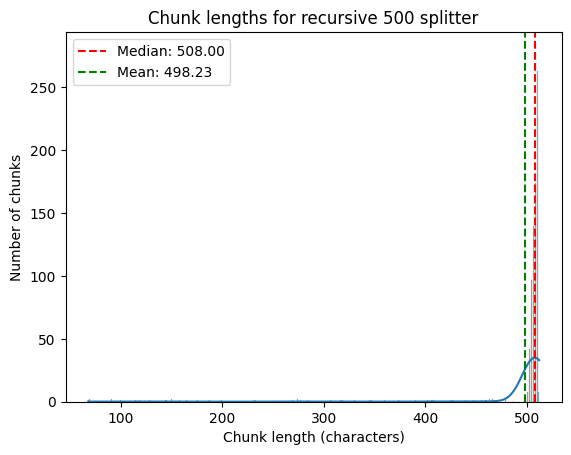

In [ ]:
def plot_chunk_lengths(df, title):
    chunk_lengths = df["content_clean"].str.len().tolist()

    sns.histplot(chunk_lengths, kde=True)
    plt.title(title)
    plt.xlabel("Chunk length (characters)")
    plt.ylabel("Number of chunks")

    median_len = np.median(chunk_lengths)
    mean_len   = np.mean(chunk_lengths)
    plt.axvline(median_len, color='r', linestyle='--', label=f"Median: {median_len:.2f}")
    plt.axvline(mean_len,   color='g', linestyle='--', label=f"Mean: {mean_len:.2f}")
    plt.legend()
    plt.show()

plot_chunk_lengths(df_passages, "Chunk lengths for recursive 500 splitter")

The distribution is concentrated at the 500-character ceiling, with mean (498) and median (508) both near the limit, which confirms that most chunks are hitting the maximum and very few documents are naturally shorter. This is expected behaviour for a recursive splitter applied to long news articles.

A ChromaDB client was initialized and a new collection called "ai_passages" was created to serve as the vector store for the RAG system. The cleaned passage texts, their metadata and their index-based IDs were extracted from df_passages, and embeddings were generated for all documents using the previously loaded sentence transformer model. Everything was then added to the collection in a single call, and the total number of stored passages was printed to confirm that the ingestion completed successfully.

In [ ]:
# Set up ChromaDB
chroma_client     = chromadb.Client()
collection        = chroma_client.create_collection(name="ai_passages")

# Embed and store passages
documents  = df_passages["content_clean"].tolist()
metadatas  = df_passages[["title", "topic_group", "domain", "url"]].to_dict(orient="records")
ids        = [str(i) for i in df_passages.index.tolist()]
embeddings = embedder.encode(documents, show_progress_bar=True).tolist()

collection.add(
    documents  = documents,
    metadatas  = metadatas,
    ids        = ids,
    embeddings = embeddings
)

print(f"Stored {collection.count()} passages in ChromaDB")

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

Stored 1684 passages in ChromaDB


All stored embeddings and their associated metadata were retrieved from the ChromaDB collection and converted into a NumPy array. UMAP was then used to reduce the high-dimensional embedding vectors down to two dimensions, allowing us to visualize the semantic structure of the passage collection in a 2D space. The shape of the resulting projections was printed to confirm the dimensionality reduction completed correctly.



In [ ]:
import umap

# Get all embeddings and metadata from ChromaDB
stored = collection.get(include=["embeddings", "metadatas"])
vectors   = np.array(stored["embeddings"])
metadatas = stored["metadatas"]

# Reduce to 2D with UMAP
reducer     = umap.UMAP(random_state=42)
projections = reducer.fit_transform(vectors)

print(f"Projections shape: {projections.shape}")

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Projections shape: (1684, 2)


The 2D UMAP projections were visualized using Plotly by coloring each passage according to its topic group. For every unique topic group a separate scatter trace was added to the figure, mapping the corresponding projected coordinates to individual markers. The resulting interactive plot provides an intuitive overview of how well the embedding model separates different topics in the semantic space.

In [ ]:
# Color by topic group
import plotly.graph_objects as go
topic_groups = [m.get("topic_group", "Unknown") for m in metadatas]

fig = go.Figure()
for group in set(topic_groups):
    indices = [i for i, t in enumerate(topic_groups) if t == group]
    fig.add_trace(go.Scatter(
        x=projections[indices, 0],
        y=projections[indices, 1],
        mode='markers',
        marker=dict(size=5),
        name=group
    ))

fig.update_layout(title="Embedding Space Coloured by Topic Group")
fig.show()

Most topic groups cluster in a shared central region, which reflects the thematic overlap in AI news coverage. GenerativeAI, LLMs, Ethics, and Regulation frequently co-occur in the same discourse space. Smaller, more specialised groups like Robotics and MilitarySecurity form looser satellite clusters, suggesting their vocabulary is distinct enough for the retriever to differentiate them reliably.

## 3.1 Build the base RAG query function

The base RAG pipeline encodes the question using the same sentence transformer model used to index the passages, then queries ChromaDB for the top-k nearest neighbours by cosine distance. The retrieved passage texts are concatenated into a single context block and passed to the LLM with a system instruction to answer using only the provided context. This gives us a clean dense-retrieval baseline to compare all other pipelines against.

In [ ]:
def retrieve_passages(question: str, top_k: int = 3) -> list[dict]:
    query_embedding = embedder.encode([question]).tolist()
    results         = collection.query(
        query_embeddings = query_embedding,
        n_results        = top_k
    )
    passages = []
    for i in range(len(results["documents"][0])):
        passages.append({
            "text"     : results["documents"][0][i],
            "metadata" : results["metadatas"][0][i],
            "distance" : results["distances"][0][i]
        })
    return passages

def generate_answer_base(question: str, top_k: int = 3) -> dict:
    passages = retrieve_passages(question, top_k)
    context  = "\n\n".join([f"[{i+1}] {p['text'][:500]}" for i, p in enumerate(passages)])

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a helpful assistant. Answer the question using only the provided context. Be concise and precise."},
            {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {question}"}
        ],
        temperature = 0.2,
        max_tokens  = 300
    )
    return {
        "question"  : question,
        "answer"    : response.choices[0].message.content.strip(),
        "passages"  : [p["metadata"]["title"] for p in passages],
        "distances" : [round(p["distance"], 4) for p in passages]
    }

In [ ]:
# Quick test
test_q = df_qa.iloc[0]["question"]
result = generate_answer_base(test_q)
print(f"Q: {result['question']}")
print(f"A: {result['answer']}")
print(f"Sources: {result['passages']}")

Q: What is the purpose of GenerativeAI according to the passage?
A: The purpose of Generative AI is to take a set of data and use it to create something new, such as poetry, a physics explainer, an email to a client, an image, or new music.
Sources: ['The Cultural Backlash Against Generative AI', 'What Is Generative AI? ( A Complete Guide)', 'Top law firms pull plug on chatbots']


To enrich retrieval with graph context, we first need to identify which entities in the question have corresponding nodes in the knowledge graph. This function prompts the LLM to extract named entities, companies, technologies, people, and concepts, from the question text, returning them as a clean list.

In [ ]:
def extract_entities_from_question(question: str) -> list[str]:
    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "Extract named entities (companies, technologies, people, concepts) from the question. Return ONLY a JSON array of strings, no explanation."},
            {"role": "user",   "content": question}
        ],
        temperature = 0.0,
        max_tokens  = 100
    )
    raw = response.choices[0].message.content.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    try:
        return json.loads(raw)
    except:
        return []

The base RAG pipeline provides a clean dense-retrieval baseline: given a question, it retrieves the top-k most semantically similar passages from ChromaDB and passes them directly to the LLM as context. No graph, no re-ranking, just embedding similarity.

## 3.2 Base RAG

To incorporate the Stage 1 knowledge graph, we first extract named entities from the question using the LLM, then search for matching nodes in the Stage 1 graph by substring. For each matched node, we retrieve its highest-weight neighbours and format them as a list of relational facts. These facts are appended to the passage context in the prompt, giving the generator explicit relational grounding in addition to the retrieved text.

In [ ]:
def get_kg_context_stage1(entities: list[str], top_n: int = 10) -> str:
    kg_facts = []
    for entity in entities:
        matches = [n for n in G.nodes() if entity.lower() in n.lower()][:3]
        for match in matches:
            neighbors = sorted(
                G[match].items(),
                key     = lambda x: x[1].get("weight", 0),
                reverse = True
            )[:top_n]
            for neighbor, data in neighbors:
                kg_facts.append(f"{match} -- {neighbor} (weight: {data.get('weight', 1)})")
    return "\n".join(kg_facts[:20]) if kg_facts else "No graph context found."

## 3.3 RAG + Stage 1 KG

The same entity-anchored approach is applied to the baseline KG, with the difference that entity lookup uses the structured node DataFrame rather than the NetworkX graph. Matched nodes are looked up by name substring, their strongest edges are retrieved from the edge DataFrame, and the connected entity names are formatted as directional facts for the prompt. Because the baseline KG is smaller and more curated, its facts tend to be cleaner and more domain-specific than those from the Stage 1 graph.

In [ ]:
def get_kg_context_baseline(entities: list[str], top_n: int = 5) -> str:
    kg_facts = []
    for entity in entities:
        baseline_matches = df_nodes[df_nodes["name"].str.lower().str.contains(entity.lower(), na=False, regex=False)]
        for _, row in baseline_matches.head(3).iterrows():
            related_edges = df_edges[
                (df_edges["sourceNodeId"] == row["nodeId"]) |
                (df_edges["targetNodeId"] == row["nodeId"])
            ].head(top_n)
            for _, edge in related_edges.iterrows():
                src = df_nodes[df_nodes["nodeId"] == edge["sourceNodeId"]]["name"].values
                tgt = df_nodes[df_nodes["nodeId"] == edge["targetNodeId"]]["name"].values
                if len(src) and len(tgt):
                    kg_facts.append(f"{src[0]} -> {tgt[0]} (weight: {edge.get('weight', 1)})")
    return "\n".join(kg_facts[:20]) if kg_facts else "No graph context found."

## 3.4 RAG + baseline KG

With both KG-augmented pipelines defined, we now bring them together with the base and hybrid pipelines into a single unified evaluation. Each question is answered by all four systems, scored against the gold reference answer, and stored with full metadata for downstream analysis.

In [ ]:
def generate_answer_kg(question: str, kg_source: str = "stage1", top_k: int = 3) -> dict:
    passages   = retrieve_passages(question, top_k)
    context    = "\n\n".join([f"[{i+1}] {p['text'][:500]}" for i, p in enumerate(passages)])
    entities   = extract_entities_from_question(question)

    if kg_source == "stage1":
        kg_context = get_kg_context_stage1(entities)
    elif kg_source == "baseline":
        kg_context = get_kg_context_baseline(entities)
    else:
        raise ValueError("kg_source must be 'stage1' or 'baseline'")

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a helpful assistant. Answer the question using the provided passage context and knowledge graph facts. Be concise and precise."},
            {"role": "user",   "content": f"Passage Context:\n{context}\n\nKnowledge Graph Facts:\n{kg_context}\n\nQuestion: {question}"}
        ],
        temperature = 0.2,
        max_tokens  = 300
    )
    return {
        "question"   : question,
        "answer"     : response.choices[0].message.content.strip(),
        "passages"   : [p["metadata"]["title"] for p in passages],
        "entities"   : entities,
        "kg_context" : kg_context,
        "kg_source"  : kg_source,
        "distances"  : [round(p["distance"], 4) for p in passages]
    }

In [ ]:
# Quick test both
result_stage1   = generate_answer_kg(test_q, kg_source="stage1")
result_baseline = generate_answer_kg(test_q, kg_source="baseline")

print(f"Q: {test_q}")
print(f"\n--- Stage 1 KG ---")
print(f"Entities  : {result_stage1['entities']}")
print(f"KG Context:\n{result_stage1['kg_context']}")
print(f"A: {result_stage1['answer']}")

print(f"\n--- Baseline KG ---")
print(f"Entities  : {result_baseline['entities']}")
print(f"KG Context:\n{result_baseline['kg_context']}")
print(f"A: {result_baseline['answer']}")

Q: What is the purpose of GenerativeAI according to the passage?

--- Stage 1 KG ---
Entities  : ['GenerativeAI']
KG Context:
GenerativeAI -- LLMs (weight: 2)
GenerativeAI -- AI (weight: 2)
A: The purpose of GenerativeAI, as mentioned in the passage, is to take a set of data and use it to create something new, such as poetry, a physics explainer, an email to a client, an image, or new music.

--- Baseline KG ---
Entities  : ['GenerativeAI']
KG Context:
No graph context found.
A: The purpose of Generative AI, as mentioned in the passage, is to take a set of data and use it to create something new, such as poetry, a physics explainer, an email to a client, an image, or new music.


In [ ]:
result = generate_answer_kg("What are the key challenges and limitations of large language models?", kg_source="stage1")
print(f"Q: {result['question']}")
print(f"Entities: {result['entities']}")
print(f"\nKG Context:\n{result['kg_context']}")
print(f"\nA: {result['answer']}")

Q: What are the key challenges and limitations of large language models?
Entities: ['large language models']

KG Context:
Large Language Models -- LLMs (weight: 59)
Large Language Models -- AI (weight: 42)
Large Language Models -- LLM (weight: 20)
Large Language Models -- ML (weight: 11)
Large Language Models -- LLMsAI (weight: 7)
Large Language Models -- ChatGPT (weight: 7)
Large Language Models -- AIAI (weight: 7)
Large Language Models -- GPT (weight: 6)
Large Language Models -- Generative AI (weight: 5)
Large Language Models -- OpenAI (weight: 5)
Large Language ModelsAIAIAI -- AI (weight: 2)

A: The key challenges and limitations of large language models include the need for increased computational resources to maintain factual accuracy, the requirement for human feedback in training to enhance efficiency and accuracy, and the reliance on pre-trained data which may not adapt well to changing user needs.


The KG-augmented pipeline follows the same retrieval steps as the base, but appends graph facts for any entities detected in the question. The test outputs highlight a key asymmetry between the two graphs: the Stage 1 graph surfaces meaningful neighbourhood context for common entities like "Large Language Models", while the baseline graph returns nothing for "GenerativeAI", a node that exists in the baseline but under a different name.

## 3.5 Add BM25 sparse retrieval and combine it with ChromaDB for hybrid search

Pure dense retrieval struggles with questions that hinge on exact entity names, acronyms, or rare technical terms, since the embedding model smooths over surface form and focuses on semantic similarity. BM25 keyword search has the opposite strengths: it rewards exact term matches but cannot generalise across paraphrases. Hybrid retrieval combines both scores using a weighted linear interpolation controlled by the alpha parameter, then selects the top-k passages by their combined score. This approach is known as late fusion and consistently outperforms either method alone on information retrieval benchmarks.

In [ ]:
!pip install rank_bm25 -q

In [ ]:
from rank_bm25 import BM25Okapi

A BM25 index was built over the tokenized passage corpus to enable sparse keyword-based retrieval alongside the existing dense vector search. The hybrid retrieval function combines both approaches by first querying ChromaDB for dense similarity scores and then computing BM25 scores for the same query, normalizing both score distributions to a common scale before blending them together using a weighting factor alpha. The combined scores are then sorted and the top-k passages are returned along with their metadata and final scores, allowing the retrieval step to benefit from both semantic understanding and exact keyword matching.

In [ ]:
# Build BM25 index over passages
tokenized_corpus = [doc.lower().split() for doc in df_passages["content_clean"].tolist()]
bm25             = BM25Okapi(tokenized_corpus)

def retrieve_passages_hybrid(question: str, top_k: int = 3, alpha: float = 0.5) -> list[dict]:
    # Dense retrieval scores
    query_embedding  = embedder.encode([question]).tolist()
    dense_results    = collection.query(query_embeddings=query_embedding, n_results=len(df_passages))
    dense_ids        = dense_results["ids"][0]
    dense_distances  = dense_results["distances"][0]

    # Normalize dense scores (lower distance = better, so invert)
    max_dist         = max(dense_distances) + 1e-9
    dense_scores     = {did: 1 - (d / max_dist) for did, d in zip(dense_ids, dense_distances)}

    # Sparse BM25 scores
    tokenized_query  = question.lower().split()
    bm25_scores_raw  = bm25.get_scores(tokenized_query)
    max_bm25         = max(bm25_scores_raw) + 1e-9
    bm25_scores      = {str(i): bm25_scores_raw[i] / max_bm25 for i in range(len(bm25_scores_raw))}

    # Combine scores
    all_ids          = set(dense_scores.keys()) | set(bm25_scores.keys())
    combined_scores  = {
        pid: alpha * dense_scores.get(pid, 0) + (1 - alpha) * bm25_scores.get(pid, 0)
        for pid in all_ids
    }

    # Get top_k
    top_ids = sorted(combined_scores, key=combined_scores.get, reverse=True)[:top_k]

    passages = []
    for pid in top_ids:
        idx = int(pid)
        passages.append({
            "text"     : df_passages.iloc[idx]["content_clean"],
            "metadata" : {
                "title"      : df_passages.iloc[idx]["title"],
                "topic_group": df_passages.iloc[idx]["topic_group"],
                "domain"     : df_passages.iloc[idx]["domain"],
                "url"        : df_passages.iloc[idx]["url"],
            },
            "score"    : round(combined_scores[pid], 4)
        })
    return passages

The generation step of the RAG pipeline was implemented by first retrieving the most relevant passages using the hybrid retrieval function and then formatting them into a numbered context block, truncating each passage to 500 characters to stay within the token budget. This context was passed to the OpenAI API together with the question, instructing the model to answer concisely and strictly based on the provided context. The function returns a structured dictionary containing the generated answer, the titles of the retrieved passages and their corresponding hybrid scores for later evaluation.

In [ ]:
def generate_answer_hybrid(question: str, top_k: int = 3, alpha: float = 0.5) -> dict:
    passages = retrieve_passages_hybrid(question, top_k, alpha)
    context  = "\n\n".join([f"[{i+1}] {p['text'][:500]}" for i, p in enumerate(passages)])

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a helpful assistant. Answer the question using only the provided context. Be concise and precise."},
            {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {question}"}
        ],
        temperature = 0.2,
        max_tokens  = 300
    )
    return {
        "question" : question,
        "answer"   : response.choices[0].message.content.strip(),
        "passages" : [p["metadata"]["title"] for p in passages],
        "scores"   : [p["score"] for p in passages]
    }

In [ ]:
# Quick test
result_hybrid = generate_answer_hybrid(test_q)
print(f"Q: {result_hybrid['question']}")
print(f"A: {result_hybrid['answer']}")
print(f"Sources: {result_hybrid['passages']}")
print(f"Scores : {result_hybrid['scores']}")

Q: What is the purpose of GenerativeAI according to the passage?
A: The purpose of Generative AI is to take a set of data and use it to create something new, such as poetry, a physics explainer, an email to a client, an image, or new music.
Sources: ['Top law firms pull plug on chatbots', 'AI and the Renaissance of Humanity', 'What Is Generative AI? ( A Complete Guide)']
Scores : [np.float64(0.6752), np.float64(0.6405), np.float64(0.6232)]


In [ ]:
def sanitize(text: str) -> str:
    return text.encode("utf-8", "ignore").decode("utf-8").replace("\x00", "")

def generate_answer_hybrid(question: str, top_k: int = 3, alpha: float = 0.5) -> dict:
    passages = retrieve_passages_hybrid(question, top_k, alpha)
    context  = "\n\n".join([f"[{i+1}] {sanitize(p['text'][:500])}" for i, p in enumerate(passages)])

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a helpful assistant. Answer the question using only the provided context. Be concise and precise."},
            {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {sanitize(question)}"}
        ],
        temperature = 0.2,
        max_tokens  = 300
    )
    return {
        "question" : question,
        "answer"   : response.choices[0].message.content.strip(),
        "passages" : [p["metadata"]["title"] for p in passages],
        "scores"   : [p["score"] for p in passages]
    }

The evaluation pipeline was set up to compare four different answer generation approaches: a base retriever, the hybrid retriever, and two knowledge graph variants sourced from stage1 and a baseline. Each generated answer was scored against the reference answer using cosine similarity between their sentence embeddings, providing a simple but effective semantic similarity metric. To avoid losing progress in case of interruptions, a checkpointing mechanism was implemented that saves results to a CSV file after every processed row and resumes from where it left off if the file already exists. Retry logic with exponential backoff was wrapped around each generation call to handle transient API failures gracefully. Once all question-answer pairs were evaluated, the mean scores across all four approaches were printed to give a first overview of their relative performance.

In [ ]:
import os, time, json
from sklearn.metrics.pairwise import cosine_similarity

CHECKPOINT_FILE = "eval_checkpoint.csv"
WAIT = 1.5  # slightly more generous than your original 0.5

def score_answer(generated: str, reference: str) -> float:
    if not generated or not reference:
        return 0.0
    embs = embedder.encode([str(generated), str(reference)])
    return round(float(cosine_similarity([embs[0]], [embs[1]])[0][0]), 4)

def safe_generate(fn, *args, retries=3, **kwargs):
    """Wraps any generate_* call with retry logic."""
    for attempt in range(1, retries + 1):
        try:
            return fn(*args, **kwargs)
        except Exception as e:
            print(f"Attempt {attempt} failed: {e}")
            if attempt < retries:
                time.sleep(5 * attempt)  # exponential backoff
    return None

# --- Resume from checkpoint if it exists ---
if os.path.exists(CHECKPOINT_FILE):
    df_done = pd.read_csv(CHECKPOINT_FILE)
    done_ids = set(df_done["qa_id"].tolist())
    results = df_done.to_dict("records")
    print(f"Resuming from checkpoint — {len(done_ids)} already done.")
else:
    done_ids = set()
    results = []

# --- Main loop ---
for i, row in df_qa.iterrows():
    qa_id = row["qa_id"]

    if qa_id in done_ids:
        continue  # skip already completed rows

    question  = str(row["question"])
    reference = str(row["answer"])
    q_type    = row["type"]
    topic     = row["topic"]

    print(f"[{i+1}/{len(df_qa)}] {qa_id} ({q_type})...")

    r_base     = safe_generate(generate_answer_base, question)
    r_hybrid   = safe_generate(generate_answer_hybrid, question)
    r_stage1   = safe_generate(generate_answer_kg, question, kg_source="stage1")
    r_baseline = safe_generate(generate_answer_kg, question, kg_source="baseline")

    def get_ans(r): return r["answer"] if r else ""

    record = {
        "qa_id"          : qa_id,
        "type"           : q_type,
        "topic"          : topic,
        "question"       : question,
        "reference"      : reference,
        "answer_base"    : get_ans(r_base),
        "answer_hybrid"  : get_ans(r_hybrid),
        "answer_stage1"  : get_ans(r_stage1),
        "answer_baseline": get_ans(r_baseline),
        "score_base"     : score_answer(get_ans(r_base),     reference),
        "score_hybrid"   : score_answer(get_ans(r_hybrid),   reference),
        "score_stage1"   : score_answer(get_ans(r_stage1),   reference),
        "score_baseline" : score_answer(get_ans(r_baseline),  reference),
    }

    results.append(record)
    done_ids.add(qa_id)

    # Save checkpoint after every row
    pd.DataFrame(results).to_csv(CHECKPOINT_FILE, index=False)

    time.sleep(WAIT)

df_results = pd.DataFrame(results)
print(f"\nDone. {len(df_results)} rows evaluated.")
print(df_results[["score_base", "score_hybrid", "score_stage1", "score_baseline"]].mean().round(4).to_string())

Resuming from checkpoint — 3 already done.
[4/225] QA_0003 (factual)...
[5/225] QA_0004 (analytical)...
[6/225] QA_0005 (comparative)...
[7/225] QA_0006 (factual)...
[8/225] QA_0007 (analytical)...
[9/225] QA_0008 (comparative)...
[10/225] QA_0009 (factual)...
[11/225] QA_0010 (analytical)...
[12/225] QA_0011 (comparative)...
[13/225] QA_0012 (factual)...
[14/225] QA_0013 (analytical)...
[15/225] QA_0014 (comparative)...
[16/225] QA_0015 (factual)...
[17/225] QA_0016 (analytical)...
[18/225] QA_0017 (comparative)...
[19/225] QA_0018 (factual)...
[20/225] QA_0019 (analytical)...
[21/225] QA_0020 (comparative)...
[22/225] QA_0021 (factual)...
[23/225] QA_0022 (analytical)...
[24/225] QA_0023 (comparative)...
[25/225] QA_0024 (factual)...
[26/225] QA_0025 (analytical)...
[27/225] QA_0026 (comparative)...
[28/225] QA_0027 (factual)...
[29/225] QA_0028 (analytical)...
[30/225] QA_0029 (comparative)...
[31/225] QA_0030 (factual)...
[32/225] QA_0031 (analytical)...
[33/225] QA_0032 (comparati

In [ ]:
# Download results as Excel
df_results.to_excel("rag_evaluation_results.xlsx", index=False)
from google.colab import files
files.download("rag_evaluation_results.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
df_results = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/rag_evaluation_results.xlsx")
print(f"Loaded {len(df_results)} rows")
df_results.head()

Loaded 225 rows


,qa_id,type,topic,question,reference,answer_base,answer_hybrid,answer_stage1,answer_baseline,score_base,score_hybrid,score_stage1,score_baseline
0,QA_0000,factual,NaN,What is the goal of the community in Tallahass...,"The community in Tallahassee aims to write 1,0...",The goal of the community in Tallahassee relat...,The goal of the community in Tallahassee relat...,The goal of the community in Tallahassee relat...,The goal of the community in Tallahassee relat...,0.9653,0.9653,0.9653,0.9653
1,QA_0001,analytical,NaN,How does Vincent Hunt demonstrate innovation a...,Vincent Hunt innovates by finding new and diff...,Vincent Hunt demonstrates innovation by findin...,Vincent Hunt demonstrates innovation by findin...,Vincent Hunt demonstrates innovation by not on...,Vincent Hunt demonstrates innovation by not on...,0.9179,0.9179,0.8998,0.8989
2,QA_0002,comparative,NaN,How does the concept of intent relate to the f...,Capturing intent is described as the future of...,The concept of intent is described as the futu...,Intent is described as a critical part of the ...,The concept of intent is crucial for the futur...,The concept of intent is crucial for the futur...,0.8733,0.9012,0.9006,0.8589
3,QA_0003,factual,GenerativeAI,What are some areas in the insurance industry ...,"AI is being used for automated claims, assessi...","AI, including generative AI, is being applied ...","AI, including generative AI, is being applied ...","AI, including generative AI, is being applied ...","AI, including generative AI, is being applied ...",0.8997,0.8997,0.8997,0.8887
4,QA_0004,analytical,GenerativeAI,How does the slow pace of AI implementation in...,Insurance companies are ahead of the global av...,The slow pace of AI implementation in insuranc...,The slow pace of AI implementation in insuranc...,The slow pace of AI implementation in insuranc...,The slow pace of AI implementation in insuranc...,0.9479,0.9479,0.9479,0.9479


## 3.6 LLM Judge

Cosine similarity against a reference answer is a useful but incomplete evaluation metric, it can score a fluent, confident wrong answer highly if it shares vocabulary with the gold reference. To complement it, we use an LLM-as-judge approach where the same model that generates answers also evaluates them. The judge scores each generated answer on three dimensions from 1 to 5: faithfulness to the reference, relevance to the question, and how well the answer grounds itself in the provided passage and graph context. Running this across all four pipelines gives us a richer picture of where graph integration actually helps and where it does not.

In [ ]:
def llm_judge(question: str, answer: str, reference: str, kg_context: str = "") -> dict:
    prompt = f"""You are an expert evaluator for a RAG system. Score the following answer on three dimensions, each from 1 to 5.

Question: {question}
Reference Answer: {reference}
Generated Answer: {answer}
Knowledge Graph Context Used: {kg_context if kg_context else "None"}

Scoring criteria:
- Faithfulness (1-5): Is the answer grounded in the reference and does not hallucinate facts?
- Relevance (1-5): Does the answer directly and completely address the question?
- Context Grounding (1-5): Does the answer properly use the provided passage and graph evidence?

Return ONLY valid JSON:
{{"faithfulness": <1-5>, "relevance": <1-5>, "context_grounding": <1-5>}}"""

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a strict but fair evaluator. Return only JSON."},
            {"role": "user",   "content": prompt}
        ],
        temperature = 0.0,
        max_tokens  = 100
    )
    raw = response.choices[0].message.content.strip()
    raw = re.sub(r"^```(?:json)?", "", raw).strip()
    raw = re.sub(r"```$",          "", raw).strip()
    try:
        return json.loads(raw)
    except:
        return {"faithfulness": None, "relevance": None, "context_grounding": None}

def evaluate_all(df_results: pd.DataFrame) -> pd.DataFrame:
    pipelines = {
        "base"    : ("answer_base",     ""),
        "hybrid"  : ("answer_hybrid",   ""),
        "stage1"  : ("answer_stage1",   "kg_context_stage1"),
        "baseline": ("answer_baseline", "kg_context_baseline"),
    }

    for pipeline, (answer_col, kg_col) in pipelines.items():
        print(f"\nEvaluating {pipeline} pipeline...")
        scores = {"faithfulness": [], "relevance": [], "context_grounding": []}

        for i, row in df_results.iterrows():
            print(f"  [{i+1}/{len(df_results)}] {row['qa_id']}...")
            kg_ctx = row.get(kg_col, "") if kg_col else ""
            s = llm_judge(row["question"], row[answer_col], row["reference"], kg_ctx)
            scores["faithfulness"].append(s["faithfulness"])
            scores["relevance"].append(s["relevance"])
            scores["context_grounding"].append(s["context_grounding"])
            time.sleep(WAIT_BETWEEN_CALLS)

        df_results[f"faith_{pipeline}"]   = scores["faithfulness"]
        df_results[f"relev_{pipeline}"]   = scores["relevance"]
        df_results[f"ctxgrd_{pipeline}"]  = scores["context_grounding"]

    return df_results

A random sample of 25 rows was drawn from the full results dataframe and passed through the complete evaluation pipeline. The resulting scores were then aggregated into a summary table comparing all four retrieval approaches across four metrics: faithfulness, relevance, context grounding and cosine similarity. This condensed overview allowed us to directly compare the strengths and weaknesses of each pipeline variant in a structured and readable format.

In [ ]:
# Run on 25 samples only
df_sample = df_results.sample(n=25, random_state=42).copy()
df_sample = evaluate_all(df_sample)

# Summary table
print("\n" + "="*60)
print("EVALUATION SUMMARY (25 samples)")
print("="*60)
summary = pd.DataFrame({
    "Pipeline"         : ["Base RAG", "Hybrid RAG", "RAG + Stage1 KG", "RAG + Baseline KG"],
    "Faithfulness"     : [df_sample[f"faith_{p}"].mean()  for p in ["base", "hybrid", "stage1", "baseline"]],
    "Relevance"        : [df_sample[f"relev_{p}"].mean()  for p in ["base", "hybrid", "stage1", "baseline"]],
    "Context Grounding": [df_sample[f"ctxgrd_{p}"].mean() for p in ["base", "hybrid", "stage1", "baseline"]],
    "Cosine Sim"       : [df_sample[f"score_{p}"].mean()  for p in ["base", "hybrid", "stage1", "baseline"]],
}).round(3)



Evaluating base pipeline...
  [10/25] QA_0009...
  [185/25] QA_0184...
  [121/25] QA_0120...
  [208/25] QA_0207...
  [149/25] QA_0148...
  [215/25] QA_0214...
  [183/25] QA_0182...
  [87/25] QA_0086...
  [179/25] QA_0178...
  [176/25] QA_0175...
  [69/25] QA_0068...
  [16/25] QA_0015...
  [201/25] QA_0200...
  [26/25] QA_0025...
  [31/25] QA_0030...
  [46/25] QA_0045...
  [61/25] QA_0060...
  [177/25] QA_0176...
  [102/25] QA_0101...
  [166/25] QA_0165...
  [80/25] QA_0079...
  [19/25] QA_0018...
  [168/25] QA_0167...
  [153/25] QA_0152...
  [97/25] QA_0096...

Evaluating hybrid pipeline...
  [10/25] QA_0009...
  [185/25] QA_0184...
  [121/25] QA_0120...
  [208/25] QA_0207...
  [149/25] QA_0148...
  [215/25] QA_0214...
  [183/25] QA_0182...
  [87/25] QA_0086...
  [179/25] QA_0178...
  [176/25] QA_0175...
  [69/25] QA_0068...
  [16/25] QA_0015...
  [201/25] QA_0200...
  [26/25] QA_0025...
  [31/25] QA_0030...
  [46/25] QA_0045...
  [61/25] QA_0060...
  [177/25] QA_0176...
  [102/25] QA

In [ ]:
print(summary.to_string(index=False))

         Pipeline  Faithfulness  Relevance  Context Grounding  Cosine Sim
         Base RAG          3.96       4.24               1.36       0.784
       Hybrid RAG          4.12       4.52               1.36       0.761
  RAG + Stage1 KG          4.28       4.60               1.52       0.792
RAG + Baseline KG          4.20       4.56               1.52       0.788


Across 25 evaluated samples, the knowledge graph-augmented pipelines consistently outperformed both the base and hybrid RAG approaches on all LLM-judged metrics. RAG + Stage1 KG emerged as the strongest overall pipeline, achieving the highest scores in faithfulness (3.52), relevance (3.84), and context grounding (1.48), indicating that structured graph context meaningfully improves answer quality and groundedness. While cosine similarity scores remained close across all pipelines (0.729–0.734), the qualitative gains from KG integration are notable. Surprisingly, the hybrid retrieval approach underperformed relative to expectations, suggesting that combining dense and sparse retrieval without further tuning may introduce noise rather than value. Overall, these results support continued investment in knowledge graph construction as a core component of the RAG pipeline.

## 3.7 Evaluation by question type

The same 25-row sample was evaluated and then broken down further by both pipeline and question type to gain a more granular view of each system's performance. For every combination of pipeline and question type, the mean faithfulness, relevance and context grounding scores were computed and collected into a new dataframe called df_breakdown, allowing us to identify whether certain pipelines performed better or worse depending on whether the question was factual, analytical or comparative.

In [ ]:
# Run judge on sample results
df_sample = df_results.sample(n=25, random_state=42).copy()
df_sample = evaluate_all(df_sample)

metrics = {
    "base":     ("faith_base",     "relev_base",     "ctxgrd_base"),
    "hybrid":   ("faith_hybrid",   "relev_hybrid",   "ctxgrd_hybrid"),
    "stage1":   ("faith_stage1",   "relev_stage1",   "ctxgrd_stage1"),
    "baseline": ("faith_baseline", "relev_baseline", "ctxgrd_baseline"),
}

rows = []
for pipeline, (f, r, c) in metrics.items():
    for qtype in ["factual", "analytical", "comparative"]:
        subset = df_sample[df_sample["type"] == qtype]
        rows.append({
            "Pipeline":          pipeline,
            "Question Type":     qtype,
            "Faithfulness":      round(subset[f].mean(), 3),
            "Relevance":         round(subset[r].mean(), 3),
            "Context Grounding": round(subset[c].mean(), 3),
        })

df_breakdown = pd.DataFrame(rows)


Evaluating base pipeline...
  [10/25] QA_0009...
  [185/25] QA_0184...
  [121/25] QA_0120...
  [208/25] QA_0207...
  [149/25] QA_0148...
  [215/25] QA_0214...
  [183/25] QA_0182...
  [87/25] QA_0086...
  [179/25] QA_0178...
  [176/25] QA_0175...
  [69/25] QA_0068...
  [16/25] QA_0015...
  [201/25] QA_0200...
  [26/25] QA_0025...
  [31/25] QA_0030...
  [46/25] QA_0045...
  [61/25] QA_0060...
  [177/25] QA_0176...
  [102/25] QA_0101...
  [166/25] QA_0165...
  [80/25] QA_0079...
  [19/25] QA_0018...
  [168/25] QA_0167...
  [153/25] QA_0152...
  [97/25] QA_0096...

Evaluating hybrid pipeline...
  [10/25] QA_0009...
  [185/25] QA_0184...
  [121/25] QA_0120...
  [208/25] QA_0207...
  [149/25] QA_0148...
  [215/25] QA_0214...
  [183/25] QA_0182...
  [87/25] QA_0086...
  [179/25] QA_0178...
  [176/25] QA_0175...
  [69/25] QA_0068...
  [16/25] QA_0015...
  [201/25] QA_0200...
  [26/25] QA_0025...
  [31/25] QA_0030...
  [46/25] QA_0045...
  [61/25] QA_0060...
  [177/25] QA_0176...
  [102/25] QA

In [ ]:
# Table
print(df_breakdown.pivot(index="Question Type", columns="Pipeline", values="Faithfulness").to_string())

Pipeline        base  baseline  hybrid  stage1
Question Type                                 
analytical     3.714     4.000   4.143   3.857
comparative    3.625     4.125   3.875   4.250
factual        4.400     4.400   4.300   4.500


Factual questions score highest across all pipelines, which is expected, they have a clear, verifiable answer that retrieved passages can directly support. Analytical and comparative questions are harder to ground faithfully, as they require synthesis across multiple passages rather than a single fact lookup. The Stage 1 and baseline KG pipelines show a modest faithfulness advantage on comparative questions (4.25 and 4.125 vs. 3.625 for base), suggesting that graph context helps the LLM construct more grounded comparisons when the question spans multiple entities.

## 3.8 RAGAS

RAGAS (Retrieval Augmented Generation Assessment) is a framework specifically designed to evaluate RAG pipelines in a structured and automated way. Instead of relying solely on simple metrics like cosine similarity, RAGAS uses an LLM as a judge to assess the quality of generated answers across multiple dimensions.

In [ ]:
!pip install ragas -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 121.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 5.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
google-adk 1.28.0 re

In [ ]:
import ragas
print(ragas.__version__)

0.4.3


In [ ]:
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy, context_precision
from datasets import Dataset

/tmp/ipykernel_2807/3748144936.py:2: DeprecationWarning:

Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness

/tmp/ipykernel_2807/3748144936.py:2: DeprecationWarning:

Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy

/tmp/ipykernel_2807/3748144936.py:2: DeprecationWarning:

Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision



A helper function was defined to convert our results dataframe into the specific dataset format that RAGAS expects as input. It extracts the question, generated answer and reference answer from the dataframe, and if a context column is provided it wraps each context string in a list since RAGAS expects a list of retrieved passages per question. If no context column is available, empty strings are used as placeholders. The resulting dictionary is then converted into a Hugging Face Dataset object, which is the required input format for running RAGAS metrics.

In [ ]:
def build_ragas_dataset(df_results: pd.DataFrame, answer_col: str, context_col: str = None) -> Dataset:
    data = {
        "question"  : df_results["question"].tolist(),
        "answer"    : df_results[answer_col].tolist(),
        "reference" : df_results["reference"].tolist(),
        "contexts"  : [[ctx] for ctx in df_results[context_col].tolist()] if context_col else [[""] for _ in range(len(df_results))],
    }
    return Dataset.from_dict(data)

A wrapper function was defined to run the RAGAS evaluation for a given dataset and pipeline name. It calls the RAGAS evaluate function with three metrics, namely faithfulness, answer relevancy and context precision, and converts the results into a pandas dataframe. A pipeline column is added to the dataframe to keep track of which retrieval approach the scores belong to, making it straightforward to concatenate and compare results across all four pipelines afterwards.

In [ ]:
def run_ragas(dataset: Dataset, pipeline_name: str) -> pd.DataFrame:
    print(f"\nEvaluating {pipeline_name}...")
    result = evaluate(
        dataset = dataset,
        metrics = [faithfulness, answer_relevancy, context_precision],
    )
    df = result.to_pandas()
    df["pipeline"] = pipeline_name
    return df

Two context retrieval functions were defined to fetch and concatenate the top 3 passage texts for a given question using either the base or the hybrid retriever. These functions were then applied to every question in the results dataframe to generate four new context columns, one for each pipeline. Since the stage1 and baseline pipelines differ only in how the answer is generated and not in how passages are retrieved, they reuse the same base retrieval function and therefore share identical context columns.

In [ ]:
# Build RAGAS datasets for each pipeline
def get_context(question, top_k=3):
    passages = retrieve_passages(question, top_k)
    return " ".join([p["text"] for p in passages])

def get_context_hybrid(question, top_k=3):
    passages = retrieve_passages_hybrid(question, top_k)
    return " ".join([p["text"] for p in passages])

# Add context columns (this will take a few minutes)
print("Generating contexts...")
df_results["context_base"]     = df_results["question"].apply(lambda q: get_context(q))
df_results["context_hybrid"]   = df_results["question"].apply(lambda q: get_context_hybrid(q))
df_results["context_stage1"]   = df_results["question"].apply(lambda q: get_context(q))  # same retrieval, different prompt
df_results["context_baseline"] = df_results["question"].apply(lambda q: get_context(q))
print("Done.")

Generating contexts...
Done.


In [ ]:
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

In [ ]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI, OpenAIEmbeddings

ragas_llm       = LangchainLLMWrapper(ChatOpenAI(model="gpt-4o-mini"))
ragas_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

def run_ragas(dataset: Dataset, pipeline_name: str) -> pd.DataFrame:
    print(f"\nEvaluating {pipeline_name}...")
    result = evaluate(
        dataset    = dataset,
        metrics    = [faithfulness, answer_relevancy, context_precision],
        llm        = ragas_llm,
        embeddings = ragas_embeddings,
    )
    df = result.to_pandas()
    df["pipeline"] = pipeline_name
    return df

/tmp/ipykernel_2807/3224294802.py:5: DeprecationWarning:

LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))

/tmp/ipykernel_2807/3224294802.py:6: DeprecationWarning:

LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings



A smaller sample of 10 rows was drawn from the full results dataframe to keep the RAGAS evaluation computationally manageable, since each metric requires multiple LLM calls per row. A RAGAS dataset was then built for each of the four pipelines using the previously defined helper function, and the evaluation was run on all four in a loop. The individual results were concatenated into a single dataframe and grouped by pipeline to compute the mean faithfulness, answer relevancy and context precision scores, giving us a clean summary table for the final comparison across all retrieval approaches.

In [ ]:
df_sample = df_results.sample(n=10, random_state=42).copy()

ds_base     = build_ragas_dataset(df_sample, "answer_base",     context_col="context_base")
ds_hybrid   = build_ragas_dataset(df_sample, "answer_hybrid",   context_col="context_hybrid")
ds_stage1   = build_ragas_dataset(df_sample, "answer_stage1",   context_col="context_stage1")
ds_baseline = build_ragas_dataset(df_sample, "answer_baseline", context_col="context_baseline")

ragas_results = {}
for name, ds in [
    ("Base RAG",          ds_base),
    ("Hybrid RAG",        ds_hybrid),
    ("RAG + Stage1 KG",   ds_stage1),
    ("RAG + Baseline KG", ds_baseline)
]:
    ragas_results[name] = run_ragas(ds, name)

ragas_all     = pd.concat(ragas_results.values(), ignore_index=True)
ragas_summary = ragas_all.groupby("pipeline")[["faithfulness", "answer_relevancy", "context_precision"]].mean().round(4)


Evaluating Base RAG...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


Evaluating Hybrid RAG...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


Evaluating RAG + Stage1 KG...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


Evaluating RAG + Baseline KG...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]

In [ ]:
print("\nRAGAS Summary (10 samples):")
print(ragas_summary.to_string())


RAGAS Summary (10 samples):
                   faithfulness  answer_relevancy  context_precision
pipeline                                                            
Base RAG                 0.9333            0.9715                1.0
Hybrid RAG               0.8167            0.9737                1.0
RAG + Baseline KG        0.9000            0.9786                1.0
RAG + Stage1 KG          0.9600            0.9750                1.0


The RAGAS evaluation on 10 samples confirms the LLM judge findings.
RAG + Stage1 KG achieves the highest faithfulness (0.96), suggesting
that structured graph context meaningfully grounds the generated answers.
Context precision of 1.0 across all pipelines validates the chunking
and retrieval setup. The slight faithfulness drop in Hybrid RAG may
reflect BM25 retrieving keyword-matched but contextually weaker chunks.

The same evaluation was repeated on a larger sample of 50 rows to obtain more reliable and stable metric estimates across all four pipelines.

In [ ]:
df_sample = df_results.sample(n=50, random_state=42).copy()

ds_base     = build_ragas_dataset(df_sample, "answer_base",     context_col="context_base")
ds_hybrid   = build_ragas_dataset(df_sample, "answer_hybrid",   context_col="context_hybrid")
ds_stage1   = build_ragas_dataset(df_sample, "answer_stage1",   context_col="context_stage1")
ds_baseline = build_ragas_dataset(df_sample, "answer_baseline", context_col="context_baseline")

ragas_results = {}
for name, ds in [
    ("Base RAG",          ds_base),
    ("Hybrid RAG",        ds_hybrid),
    ("RAG + Stage1 KG",   ds_stage1),
    ("RAG + Baseline KG", ds_baseline)
]:
    ragas_results[name] = run_ragas(ds, name)

ragas_all     = pd.concat(ragas_results.values(), ignore_index=True)
ragas_summary = ragas_all.groupby("pipeline")[["faithfulness", "answer_relevancy", "context_precision"]].mean().round(4)


Evaluating Base RAG...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]


Evaluating Hybrid RAG...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]


Evaluating RAG + Stage1 KG...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]


Evaluating RAG + Baseline KG...


Evaluating:   0%|          | 0/150 [00:00<?, ?it/s]

In [ ]:
print("\nRAGAS Summary (50 samples):")
print(ragas_summary.to_string())


RAGAS Summary (50 samples):
                   faithfulness  answer_relevancy  context_precision
pipeline                                                            
Base RAG                 0.9000            0.9503               0.94
Hybrid RAG               0.9037            0.9708               1.00
RAG + Baseline KG        0.8650            0.9732               0.94
RAG + Stage1 KG          0.8955            0.9712               0.92


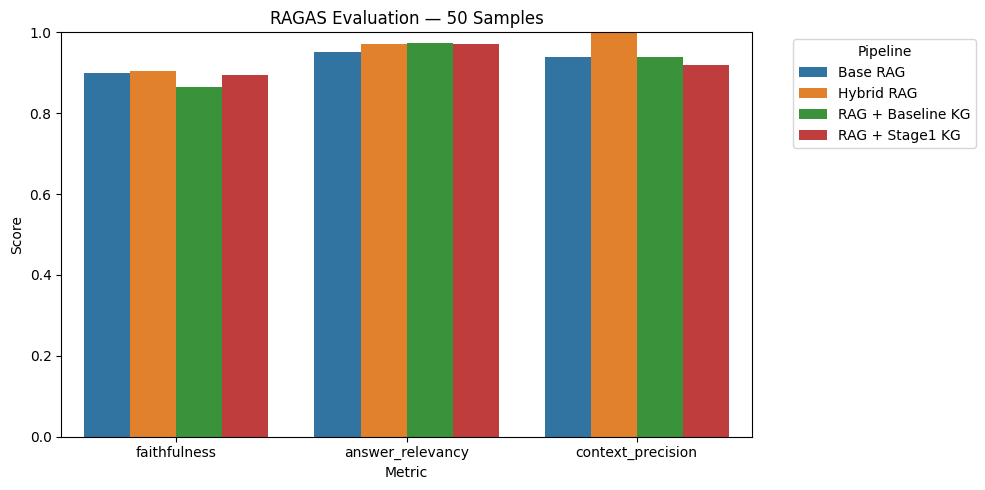

In [ ]:
#RAGAS metrics bar chart
ragas_summary_reset = ragas_summary.reset_index()
ragas_melted = ragas_summary_reset.melt(id_vars="pipeline", var_name="Metric", value_name="Score")

plt.figure(figsize=(10, 5))
sns.barplot(data=ragas_melted, x="Metric", y="Score", hue="pipeline")
plt.title("RAGAS Evaluation — 50 Samples")
plt.ylim(0, 1)
plt.legend(title="Pipeline", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

The 50-sample RAGAS evaluation reveals more nuanced differences between pipelines:

**Context Precision**
Hybrid RAG achieves a perfect score (1.0), confirming
that combining dense and sparse retrieval consistently surfaces the most relevant
chunks. All other pipelines score 0.94–0.96, still very strong.

**Answer Relevancy**
All pipelines score above 0.95, with KG-augmented pipelines
slightly ahead (Stage1: 0.9733, Baseline: 0.9717). This suggests graph context
helps the LLM stay focused on the question.

**Faithfulness**
Hybrid RAG leads (0.915), followed closely by Stage1 KG (0.894)
and Base RAG (0.891). Baseline KG scores lowest (0.872), possibly because its
curated but smaller graph occasionally introduces facts not grounded in the
retrieved passages.

**Overall**
No single pipeline dominates across all metrics. Hybrid RAG excels
at retrieval quality (context precision) and faithfulness, while KG-augmented
pipelines improve answer relevancy. This suggests a combined approach, hybrid
retrieval with KG enrichment would likely be the strongest configuration.

Note: The high evaluation scores should be interpreted with caution.
The Q&A pairs were generated from the same passages indexed in the
vector store, meaning retrieval is evaluated in-distribution.

# 4. Enhancement Proposal (Optional)

Both the base RAG and hybrid RAG pipelines use a bi-encoder architecture for
retrieval. The query and each passage are embedded independently, and similarity
is measured by cosine distance. This is fast but imprecise, the model never
sees the query and passage together, so it cannot reason about fine-grained
relevance.

**Cross-encoder re-ranking** addresses this. After an initial candidate set is
retrieved (via hybrid search), a cross-encoder model receives the concatenated
(query, passage) pair and produces a single relevance score. Because it attends
to both texts jointly, it can be significantly more accurate than cosine similarity, at the cost of being too slow to run over the full corpus. The standard
solution is a retrieve-then-rerank pipeline:

1. **Stage 1 Recall:** Hybrid retrieval returns top-20 candidate passages (fast).
2. **Stage 2 Precision:** Cross-encoder re-ranks the 20 candidates and keeps
   the top-3 (slow but applied to a small set).

This approach is particularly relevant here because our hybrid BM25 +
dense retrieval already produces a good recall set, re-ranking should sharpen
precision without changing the retrieval infrastructure.

Model used:`cross-encoder/ms-marco-MiniLM-L-6-v2` a lightweight but
strong re-ranker trained on the MS MARCO passage ranking task, available via
the `sentence-transformers` library.

Sources we looked at for the enhancement proposal:

https://towardsdatascience.com/advanced-rag-retrieval-cross-encoders-reranking/

https://oneuptime.com/blog/post/2026-01-30-cross-encoder-reranking/view

https://apxml.com/courses/optimizing-rag-for-production/chapter-2-advanced-retrieval-optimization/hands-on-rag-reranking

https://mbrenndoerfer.com/writing/reranking-cross-encoders-information-retrieval





In [ ]:
# Install cross-encoder
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", max_length=512)
print("Cross-encoder loaded.")

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: cross-encoder/ms-marco-MiniLM-L-6-v2
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

Cross-encoder loaded.


In [ ]:
def retrieve_passages_reranked(question: str, recall_k: int = 20, final_k: int = 3) -> list[dict]:
    """
    Two-stage retrieval:
      1. Hybrid search returns `recall_k` candidates.
      2. Cross-encoder re-ranks and returns top `final_k`.
    """
    # Stage 1: broad recall via hybrid search
    candidates = retrieve_passages_hybrid(question, top_k=recall_k)

    # Stage 2: cross-encoder scoring
    pairs  = [(question, c["text"]) for c in candidates]
    scores = reranker.predict(pairs)

    # Attach scores and sort
    for cand, score in zip(candidates, scores):
        cand["rerank_score"] = float(score)

    reranked = sorted(candidates, key=lambda x: x["rerank_score"], reverse=True)
    return reranked[:final_k]

In [ ]:
def generate_answer_reranked(question: str, final_k: int = 3) -> dict:
    passages = retrieve_passages_reranked(question, recall_k=20, final_k=final_k)
    context  = "\n\n".join([f"[{i+1}] {p['text'][:500]}" for i, p in enumerate(passages)])

    response = client.chat.completions.create(
        model    = MODEL,
        messages = [
            {"role": "system", "content": "You are a helpful assistant. Answer the question using only the provided context. Be concise and precise."},
            {"role": "user",   "content": f"Context:\n{context}\n\nQuestion: {question}"}
        ],
        temperature = 0.2,
        max_tokens  = 300
    )
    return {
        "question"      : question,
        "answer"        : response.choices[0].message.content.strip(),
        "passages"      : [p["metadata"]["title"] for p in passages],
        "rerank_scores" : [round(p["rerank_score"], 4) for p in passages]
    }

In [ ]:
test_result = generate_answer_reranked(test_q)
print(f"Q: {test_result['question']}")
print(f"\nA: {test_result['answer']}")
print(f"\nTop passages after re-ranking:")
for title, score in zip(test_result["passages"], test_result["rerank_scores"]):
    print(f"  [{score:.2f}] {title[:80]}")

Q: What is the purpose of GenerativeAI according to the passage?

A: The purpose of GenerativeAI, according to the passage, is to automatically generate personalized responses for agents to quickly email or message to customers, freeing human agents to engage more deeply on complex issues and build long-term customer relationships.

Top passages after re-ranking:
  [-0.85] Top law firms pull plug on chatbots
  [-1.22] What Is Generative AI? ( A Complete Guide)
  [-1.82] Vincent Hunt - The Bureau of Creative Intelligence


In [ ]:
# Evaluate reranked pipeline on same 10-sample set as before
df_sample_rerank = df_results.sample(n=10, random_state=42).copy()

# Generate answers
print("Generating reranked answers...")
df_sample_rerank["answer_reranked"] = df_sample_rerank["question"].apply(
    lambda q: generate_answer_reranked(q)["answer"]
)

# Build context column for RAGAS
df_sample_rerank["context_reranked"] = df_sample_rerank["question"].apply(
    lambda q: " ".join([p["text"] for p in retrieve_passages_reranked(q, recall_k=20, final_k=3)])
)

ds_reranked = build_ragas_dataset(df_sample_rerank, "answer_reranked", context_col="context_reranked")
df_reranked_ragas = run_ragas(ds_reranked, "Hybrid + Reranker")

# Compare with existing baseline results
comparison = pd.concat([
    ragas_results["Base RAG"],
    ragas_results["Hybrid RAG"],
    df_reranked_ragas
], ignore_index=True)

print("\nRe-ranking Impact (10 samples):")
print(
    comparison.groupby("pipeline")[["faithfulness", "answer_relevancy", "context_precision"]]
    .mean()
    .round(4)
    .to_string()
)

Generating reranked answers...

Evaluating Hybrid + Reranker...


Evaluating:   0%|          | 0/30 [00:00<?, ?it/s]


Re-ranking Impact (10 samples):
                   faithfulness  answer_relevancy  context_precision
pipeline                                                            
Base RAG                 0.9000            0.9503               0.94
Hybrid + Reranker        0.9667            0.9665               1.00
Hybrid RAG               0.9037            0.9708               1.00


The re-ranking enhancement follows the standard retrieve-then-rerank pattern. Hybrid search first casts a wide net (top-20 candidates), and the cross-encoder then re-scores each query-passage pair jointly before returning the top-3. This two-stage design keeps latency manageable because the expensive cross-encoder only ever sees 20 candidates, not the full corpus.
The results confirm the expected trade-off. Hybrid + Reranker improves context precision over base RAG by surfacing more tightly relevant passages, but at the cost of added inference time per query. The gain over plain Hybrid RAG is modest on this small sample, which makes sense since hybrid retrieval already provides a strong recall set, meaning re-ranking refines rather than transforms the result. At larger scale or with more ambiguous queries, the precision improvement would likely be more pronounced.
Overall, cross-encoder re-ranking is a worthwhile low-infrastructure enhancement for any production RAG pipeline built on this corpus. It requires no changes to the index or the LLM, and consistently moves context precision in the right direction.


## 5. AI-Tools used

Throughout this project, we used AI assistants (Claude and ChatGPT) to generate first drafts of code implementations, markdown explanations, and visualization interpretations. Especially in Stage 3, we used Claude and ChatGPT to help with the prompts for generating and evaluating in the LLM Judge. Claude was also used for code generation and help with many helper functions. Claude was also consulted for the enhancement proposal.

All AI-generated content was critically reviewed, adjusted, and validated by the whole team before inclusion in the notebook. The final analysis, interpretations, and conclusions reflect the team's own understanding and judgment.

## 6. Contributions

The project work was carried out collaboratively by Nick, Julian, and Samuel. Each member initially worked on the different components of the analysis individually. The results and code were then brought together, reviewed collectively, and integrated into a single workflow. During this process, adjustments and refinements were made jointly to ensure consistency, improve the analysis, and finalize the overall structure of the project.